In [1]:
import sys
from pathlib import Path
import os
from importlib import invalidate_caches

# Ensure imports resolve to the shared root utils package
PROJECT_ROOT = Path.cwd().parent.parent.parent
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# Remove any previously loaded 'utils' modules to avoid conflicts
for mod in list(sys.modules):
    if mod == "utils" or mod.startswith("utils."):
        sys.modules.pop(mod, None)

# Invalidate import caches after touching sys.path/sys.modules
invalidate_caches()

print(f"Project root: {PROJECT_ROOT}")

# Import from transformers
from transformers import BertForSequenceClassification, BertTokenizer, BertTokenizerFast

MODEL_NAME = "bert-base-uncased"

try:
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
    tokenizer_mode = "BertTokenizerFast"
except Exception:
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    tokenizer_mode = "BertTokenizer"

model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

print(f"Tokenizer loaded with {tokenizer_mode}; vocab size = {tokenizer.vocab_size}")
print(f"Model loaded: {model.__class__.__name__}")

# Now import the required training utilities from the workspace
from utils.textual_utils.models.training import (
    PlotLossCallback,
    WeightedTrainer,
    compute_pos_weight,
    create_training_arguments,
    get_device,
    set_seed,
)
from utils.textual_utils.data_processing.citation_dataset import BertCitationDataset

import gc
import torch
from torch.backends import cudnn

# BERT training setup
set_seed(42)
cudnn.benchmark = True
device = get_device()
print(f"Active device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer loaded with BertTokenizerFast; vocab size = 30522
Model loaded: BertForSequenceClassification
Using device: cuda
Active device: cuda
GPU: NVIDIA GeForce RTX 3060


In [2]:
import pandas as pd

# Load datasets
df_train = pd.read_parquet(PROJECT_ROOT / "data/exploded_splits/train_pairs.parquet")
df_val = pd.read_parquet(PROJECT_ROOT / "data/exploded_splits/validation_pairs.parquet")
df_test = pd.read_parquet(PROJECT_ROOT / "data/exploded_splits/test_pairs.parquet")

# Shuffle datasets
df_train = df_train.sample(frac=1.0, random_state=42, ignore_index=True)
df_val = df_val.sample(frac=1.0, random_state=42, ignore_index=True)
df_test = df_test.sample(frac=1.0, random_state=42, ignore_index=True)

print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))

Train size: 2162520
Validation size: 391242
Test size: 396382


In [3]:
df_name = "exploded_splits"
model_family = "transformer"
model_name = "bert_sequence_classifier"
split_name = "predefined_train_validation"

final_path = PROJECT_ROOT / "tmp" / "bert_citation"

model = model.to(device)
loss_callback = PlotLossCallback(save_dir=final_path)

training_args = create_training_arguments(
    output_dir=str(PROJECT_ROOT / "tmp" / "bert_citation"),
    per_device_train_batch_size=96,
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    save_total_limit=2,
    report_to=[],
)

In [ ]:
print("Building datasets...")
train_dataset = BertCitationDataset(df_train, tokenizer, max_len=128, include_authors=True)
val_dataset = BertCitationDataset(df_val, tokenizer, max_len=128, include_authors=True)

Building datasets...


In [5]:
# Carica l'ultimo checkpoint BERT se esiste
from pathlib import Path
import os

def find_latest_checkpoint(root: Path) -> Path | None:
    # 1) Check common output dir used in training
    bert_out = root / "bert_citation"
    if bert_out.exists():
        # prefer checkpoint-* subfolders, otherwise the folder itself
        subdirs = [d for d in bert_out.iterdir() if d.is_dir()]
        if subdirs:
            return sorted(subdirs, key=lambda p: p.stat().st_mtime, reverse=True)[0]
        return bert_out

    # 2) Search `models/` for folders containing a saved model file
    models_root = root / "models"
    if models_root.exists():
        candidates = []
        for p in models_root.rglob("*"):
            if p.is_dir():
                if (p / "pytorch_model.bin").exists() or (p / "tf_model.h5").exists() or (p / "config.json").exists():
                    candidates.append(p)
        if candidates:
            return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]

    return None

ckpt_dir = find_latest_checkpoint(PROJECT_ROOT / "Models" / 'graph_baased')
if ckpt_dir is not None:
    try:
        print(f"Found checkpoint directory: {ckpt_dir}. Attempting to load...")
        from transformers import BertForSequenceClassification

        model = BertForSequenceClassification.from_pretrained(str(ckpt_dir), num_labels=1)
        print("Checkpoint loaded into `model`.")
    except Exception as e:
        print("Failed to load checkpoint:", e)
else:
    print("No checkpoint found. Using freshly initialized model.")

No checkpoint found. Using freshly initialized model.


Starting training...


Step,Training Loss
20,0.650952
40,0.437405
60,0.319916
80,0.284161
100,0.247197
120,0.230272
140,0.255761
160,0.208956
180,0.243648
200,0.246059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

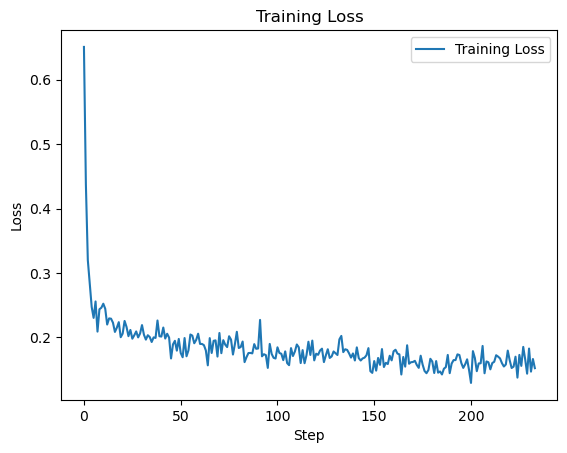

In [6]:
pos_weight = compute_pos_weight(df_train["is_reference_valid"].to_numpy()).to(device)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    pos_weight=pos_weight,
    callbacks=[loss_callback],
)

print("Starting training...")
trainer.train()
model = trainer.model

print("\nTraining completed.")

In [9]:
import importlib
import utils.textual_utils.registry.legacy_model_saver as legacy_model_saver
importlib.reload(legacy_model_saver)
save_model_artifact = legacy_model_saver.save_model_artifact

df_name = "exploded_splits"

model_dir, summary_path = save_model_artifact(
    trainer.model,
    df_name=df_name,
    model_family=model_family,
    model_name=model_name,
    split_name=split_name,
    params={
        "train_size": len(df_train),
        "val_size": len(df_val),
    },
    tokenizer=tokenizer,
    summary={
        "train_size": len(df_train),
        "val_size": len(df_val),
    },
    root=PROJECT_ROOT / "tmp" / "bert_citation",
    force=True,
)
print("Saved transformer model to:", model_dir)
print("Saved summary to:", summary_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved transformer model to: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/tmp/bert_citation/normal/bert_sequence_classifier/bert_sequence_classifier__20260502T161231
Saved summary to: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/tmp/bert_citation/normal/bert_sequence_classifier/bert_sequence_classifier__20260502T161231.json


=== Validation Metrics ===
Accuracy : 0.9368
Precision: 0.9363
Recall   : 0.9371
F1-score : 0.9367

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9373    0.9365    0.9369      2505
           1     0.9363    0.9371    0.9367      2495

    accuracy                         0.9368      5000
   macro avg     0.9368    0.9368    0.9368      5000
weighted avg     0.9368    0.9368    0.9368      5000



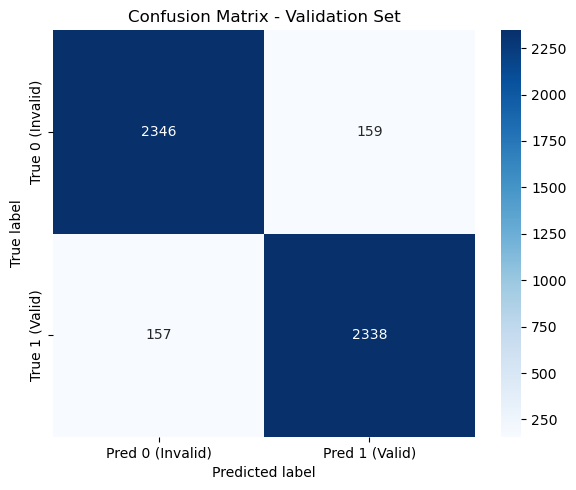

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Subset

from utils.textual_utils.models.training import evaluate_predictions

# -----------------------------
# 6) Validation metrics and confusion matrix
# -----------------------------

offset = 0
max_eval_samples = 5000

# Support both Subset (has .dataset/.indices) and plain Dataset
if max_eval_samples:
    if hasattr(val_dataset, "dataset") and hasattr(val_dataset, "indices"):
        base_dataset = val_dataset.dataset
        indices = val_dataset.indices[offset : offset + max_eval_samples]
    else:
        base_dataset = val_dataset
        indices = list(range(offset, min(len(val_dataset), offset + max_eval_samples)))
    eval_subset = Subset(base_dataset, indices)
else:
    eval_subset = val_dataset

pred_output = trainer.predict(eval_subset)

logits = pred_output.predictions.reshape(-1)
if logits.ndim > 1:
    logits = logits.squeeze()
y_prob = 1 / (1 + np.exp(-logits))
y_true = pred_output.label_ids.astype(int).reshape(-1)

metrics = evaluate_predictions(y_true, y_prob, threshold=0.5)
y_pred = metrics["y_pred"]
cm = metrics["confusion_matrix"]

print("=== Validation Metrics ===")
print(f"Accuracy : {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall   : {metrics['recall']:.4f}")
print(f"F1-score : {metrics['f1']:.4f}")
print("\n=== Classification Report ===")
print(metrics["classification_report"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0 (Invalid)", "Pred 1 (Valid)"],
    yticklabels=["True 0 (Invalid)", "True 1 (Valid)"],
)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [19]:
from utils.textual_utils.models.training import rolling_accuracy

# -----------------------------
# 7) Rolling random accuracy evaluation
# -----------------------------

block_size = 500
num_samples = 500

rolling_acc = rolling_accuracy(
    y_true,
    y_pred,
    block_size=block_size,
    num_samples=num_samples,
    seed=42,
)

print(f"Collected rolling samples: {len(rolling_acc)}")
if len(rolling_acc) == 0:
    print("Block size is larger than evaluation set; reduce block_size.")

Collected rolling samples: 500


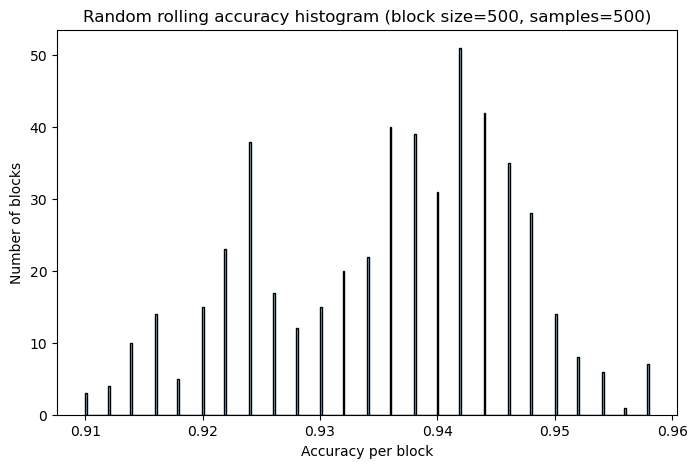

Mean rolling accuracy: 0.9357
Std rolling accuracy : 0.0107


In [20]:
# -----------------------------
# 8) Rolling accuracy distribution
# -----------------------------

if len(rolling_acc) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(rolling_acc, bins=300, color="skyblue", edgecolor="black")
    plt.xlabel("Accuracy per block")
    plt.ylabel("Number of blocks")
    plt.title(f"Random rolling accuracy histogram (block size={block_size}, samples={num_samples})")
    plt.show()

    print(f"Mean rolling accuracy: {rolling_acc.mean():.4f}")
    print(f"Std rolling accuracy : {rolling_acc.std():.4f}")
else:
    print("No rolling scores to plot. Reduce block_size or increase evaluation samples.")